# EDA — AdaBlock LLaDA on GSM8K\n\nExplores `traces/adablock/gsm8k_test_traces.jsonl` produced by `scripts/probe_adablock_llada.py`.\n\nSections:\n1. Load & flatten traces\n2. NFE distribution (per-block and per-problem)\n3. Block size distribution\n4. Stabilizing step patterns\n5. NFE vs problem difficulty proxy\n6. Per-token stabilizing step ramp within blocks

In [1]:
# Ensure required packages are available (safe to re-run; uv installs them via --group phase_cpd)
import importlib, subprocess, sys

_missing = [pkg for pkg in ["matplotlib", "numpy", "pandas", "scipy"]
            if importlib.util.find_spec(pkg) is None]
if _missing:
    print(f"Installing missing packages: {_missing}")
    %pip install --quiet matplotlib numpy pandas scipy
    print("packages ready")
else:
    print("All packages present.")

All packages present.


In [3]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

TRACE_PATH = Path("../traces/adablock/gsm8k_test_traces.jsonl")

# ── load raw traces ──────────────────────────────────────────────────────────
raw = []
with TRACE_PATH.open() as f:
    for line in f:
        line = line.strip()
        if line:
            raw.append(json.loads(line))

print(f"Loaded {len(raw)} traces")
print("Keys:", list(raw[0].keys()))

Loaded 200 traces
Keys: ['sample_id', 'prompt', 'model_name', 'dataset', 'reference_answer', 'created_at', 'decoding_config', 'generated_text', 'nfe_history', 'block_history', 'blocks', 'total_nfe', 'num_blocks', 'avg_block_size', 'avg_nfe']


In [4]:
# ── flatten to per-block dataframe ──────────────────────────────────────────
block_rows = []
token_rows = []

for trace in raw:
    sid = trace["sample_id"]
    prompt_len = len(trace["prompt"].split())  # rough word count as difficulty proxy

    for blk in trace["blocks"]:
        block_rows.append({
            "sample_id":   sid,
            "block_index": blk["block_index"],
            "block_size":  blk["block_size"],
            "nfe":         blk["nfe"],
            "prompt_words": prompt_len,
            "total_nfe":   trace["total_nfe"],
            "num_blocks":  trace["num_blocks"],
        })
        for tok in blk["tokens"]:
            token_rows.append({
                "sample_id":       sid,
                "block_index":     blk["block_index"],
                "block_size":      blk["block_size"],
                "nfe":             blk["nfe"],
                "token_index":     tok["token_index"],
                "token_text":      tok["token_text"],
                "stabilizing_step": tok["stabilizing_step"],
            })

blocks = pd.DataFrame(block_rows)
tokens = pd.DataFrame(token_rows)

# drop padding blocks (all endoftext / nfe=1 with block full of special tokens)
special_ids = {"<|endoftext|>", "<|eot_id|>"}
content_mask = tokens.groupby(["sample_id", "block_index"])["token_text"].apply(
    lambda s: (~s.isin(special_ids)).any()
)
valid_block_keys = content_mask[content_mask].index
blocks = blocks[blocks.set_index(["sample_id", "block_index"]).index.isin(valid_block_keys)].reset_index(drop=True)
tokens = tokens[tokens.set_index(["sample_id", "block_index"]).index.isin(valid_block_keys)].reset_index(drop=True)

print(f"Blocks: {len(blocks)}  |  Tokens: {len(tokens)}")
blocks.head()

Blocks: 3789  |  Tokens: 49002


,sample_id,block_index,block_size,nfe,prompt_words,total_nfe,num_blocks
0,gsm8k-test-0000,0,22,4,52,88,21
1,gsm8k-test-0000,1,1,1,52,88,21
2,gsm8k-test-0000,2,16,10,52,88,21
3,gsm8k-test-0000,3,1,1,52,88,21
4,gsm8k-test-0000,4,16,10,52,88,21


## 1. Summary statistics

In [5]:
per_problem = blocks.groupby("sample_id").agg(
    total_nfe=("nfe", "sum"),
    num_blocks=("block_index", "count"),
    mean_nfe=("nfe", "mean"),
    max_nfe=("nfe", "max"),
    mean_block_size=("block_size", "mean"),
).reset_index()

print("=== Per-problem stats ===")
print(per_problem[["total_nfe","num_blocks","mean_nfe","max_nfe"]].describe().round(2))
print()
print("=== Per-block NFE stats ===")
print(blocks["nfe"].describe().round(2))
print()
print("=== Block size stats ===")
print(blocks["block_size"].describe().round(2))

=== Per-problem stats ===
       total_nfe  num_blocks  mean_nfe  max_nfe
count     200.00      200.00    200.00   200.00
mean       79.51       18.94      4.27    12.54
std        20.10        3.54      1.06     4.40
min        32.00        9.00      2.43     6.00
25%        67.00       17.00      3.52    10.00
50%        78.00       19.00      4.11    11.00
75%        89.00       21.00      4.81    14.00
max       141.00       30.00      7.25    36.00

=== Per-block NFE stats ===
count    3789.00
mean        4.20
std         3.76
min         1.00
25%         1.00
50%         3.00
75%         6.00
max        36.00
Name: nfe, dtype: float64

=== Block size stats ===
count    3789.00
mean       12.93
std        10.40
min         1.00
25%         3.00
50%        15.00
75%        16.00
max        64.00
Name: block_size, dtype: float64


## 2. NFE distribution

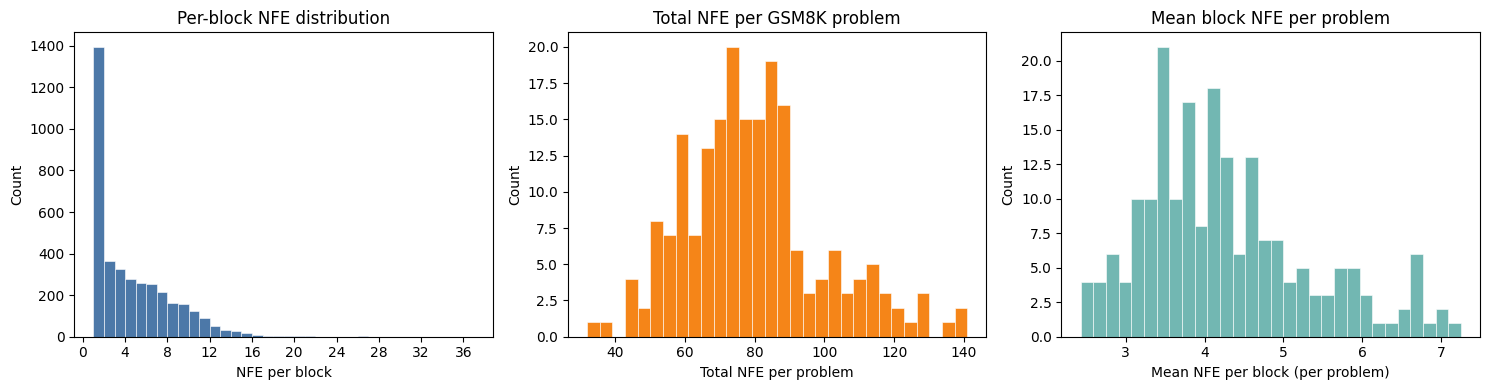

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# per-block NFE
ax = axes[0]
ax.hist(blocks["nfe"], bins=range(1, blocks["nfe"].max() + 2), edgecolor="white", linewidth=0.4, color="#4c78a8")
ax.set_xlabel("NFE per block")
ax.set_ylabel("Count")
ax.set_title("Per-block NFE distribution")
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))

# total NFE per problem
ax = axes[1]
ax.hist(per_problem["total_nfe"], bins=30, edgecolor="white", linewidth=0.4, color="#f58518")
ax.set_xlabel("Total NFE per problem")
ax.set_ylabel("Count")
ax.set_title("Total NFE per GSM8K problem")

# mean NFE per problem
ax = axes[2]
ax.hist(per_problem["mean_nfe"], bins=30, edgecolor="white", linewidth=0.4, color="#72b7b2")
ax.set_xlabel("Mean NFE per block (per problem)")
ax.set_ylabel("Count")
ax.set_title("Mean block NFE per problem")

plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_distributions.png", dpi=150)
plt.show()

## 3. NFE across block position (does difficulty grow over a response?)

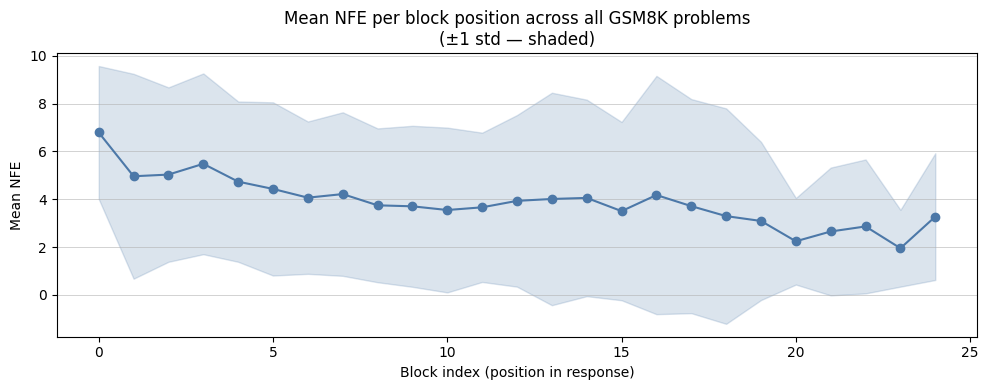

In [7]:
mean_nfe_by_pos = blocks.groupby("block_index")["nfe"].agg(["mean", "std", "count"]).reset_index()
mean_nfe_by_pos = mean_nfe_by_pos[mean_nfe_by_pos["count"] >= 10]  # drop positions with few samples

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_nfe_by_pos["block_index"], mean_nfe_by_pos["mean"], marker="o", color="#4c78a8", linewidth=1.5)
ax.fill_between(
    mean_nfe_by_pos["block_index"],
    mean_nfe_by_pos["mean"] - mean_nfe_by_pos["std"],
    mean_nfe_by_pos["mean"] + mean_nfe_by_pos["std"],
    alpha=0.2, color="#4c78a8"
)
ax.set_xlabel("Block index (position in response)")
ax.set_ylabel("Mean NFE")
ax.set_title("Mean NFE per block position across all GSM8K problems\n(±1 std — shaded)")
ax.grid(axis="y", linewidth=0.4)
plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_by_block_position.png", dpi=150)
plt.show()

## 4. Stabilizing step ramp within blocks

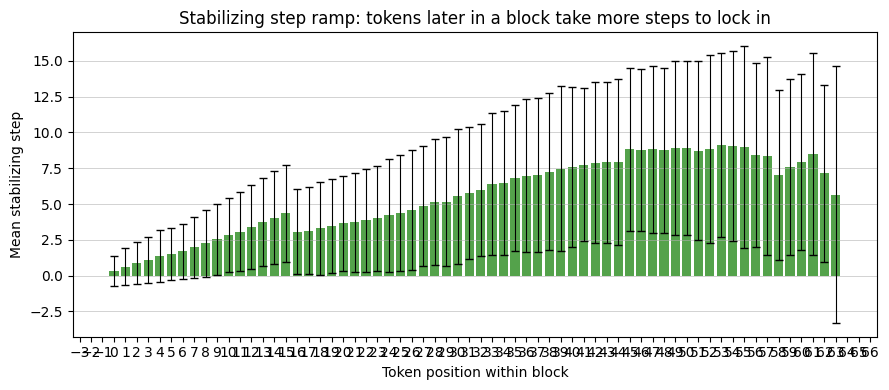

In [8]:
# mean stabilizing step by token position within block (0–15)
mean_stab = tokens.groupby("token_index")["stabilizing_step"].agg(["mean","std"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(mean_stab["token_index"], mean_stab["mean"], yerr=mean_stab["std"],
       color="#54a24b", error_kw=dict(elinewidth=0.8, capsize=3))
ax.set_xlabel("Token position within block")
ax.set_ylabel("Mean stabilizing step")
ax.set_title("Stabilizing step ramp: tokens later in a block take more steps to lock in")
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(axis="y", linewidth=0.4)
plt.tight_layout()
plt.savefig("../traces/adablock/fig_stabilizing_step_ramp.png", dpi=150)
plt.show()

## 5. NFE autocorrelation — does a hard block predict the next block?

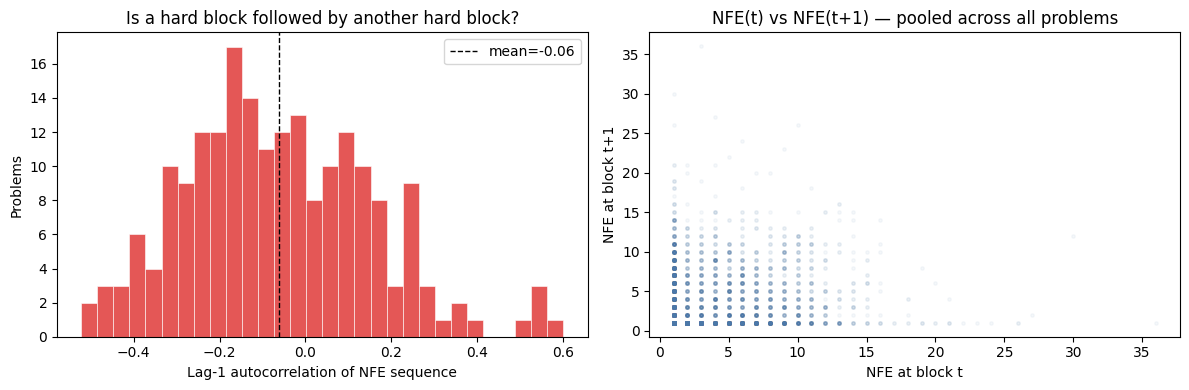

Mean lag-1 correlation: -0.062


In [9]:
from pandas.plotting import autocorrelation_plot

# build per-problem NFE sequences and compute lag-1 correlation
lag1_corrs = []
for sid, grp in blocks.sort_values("block_index").groupby("sample_id"):
    nfe_seq = grp["nfe"].values
    if len(nfe_seq) >= 3:
        lag1_corrs.append(np.corrcoef(nfe_seq[:-1], nfe_seq[1:])[0, 1])

lag1_corrs = [x for x in lag1_corrs if not math.isnan(x)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram of lag-1 correlations across problems
ax = axes[0]
ax.hist(lag1_corrs, bins=30, edgecolor="white", linewidth=0.4, color="#e45756")
ax.axvline(np.mean(lag1_corrs), color="black", linestyle="--", linewidth=1, label=f"mean={np.mean(lag1_corrs):.2f}")
ax.set_xlabel("Lag-1 autocorrelation of NFE sequence")
ax.set_ylabel("Problems")
ax.set_title("Is a hard block followed by another hard block?")
ax.legend()

# scatter nfe[t] vs nfe[t+1] pooled across all problems
pairs = []
for sid, grp in blocks.sort_values("block_index").groupby("sample_id"):
    nfe_seq = grp["nfe"].values
    for t in range(len(nfe_seq) - 1):
        pairs.append((nfe_seq[t], nfe_seq[t+1]))
pairs = np.array(pairs)

ax = axes[1]
ax.scatter(pairs[:, 0], pairs[:, 1], alpha=0.05, s=6, color="#4c78a8")
ax.set_xlabel("NFE at block t")
ax.set_ylabel("NFE at block t+1")
ax.set_title("NFE(t) vs NFE(t+1) — pooled across all problems")

plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_autocorrelation.png", dpi=150)
plt.show()
print(f"Mean lag-1 correlation: {np.mean(lag1_corrs):.3f}")

## 6. NFE heatmap — individual problem traces

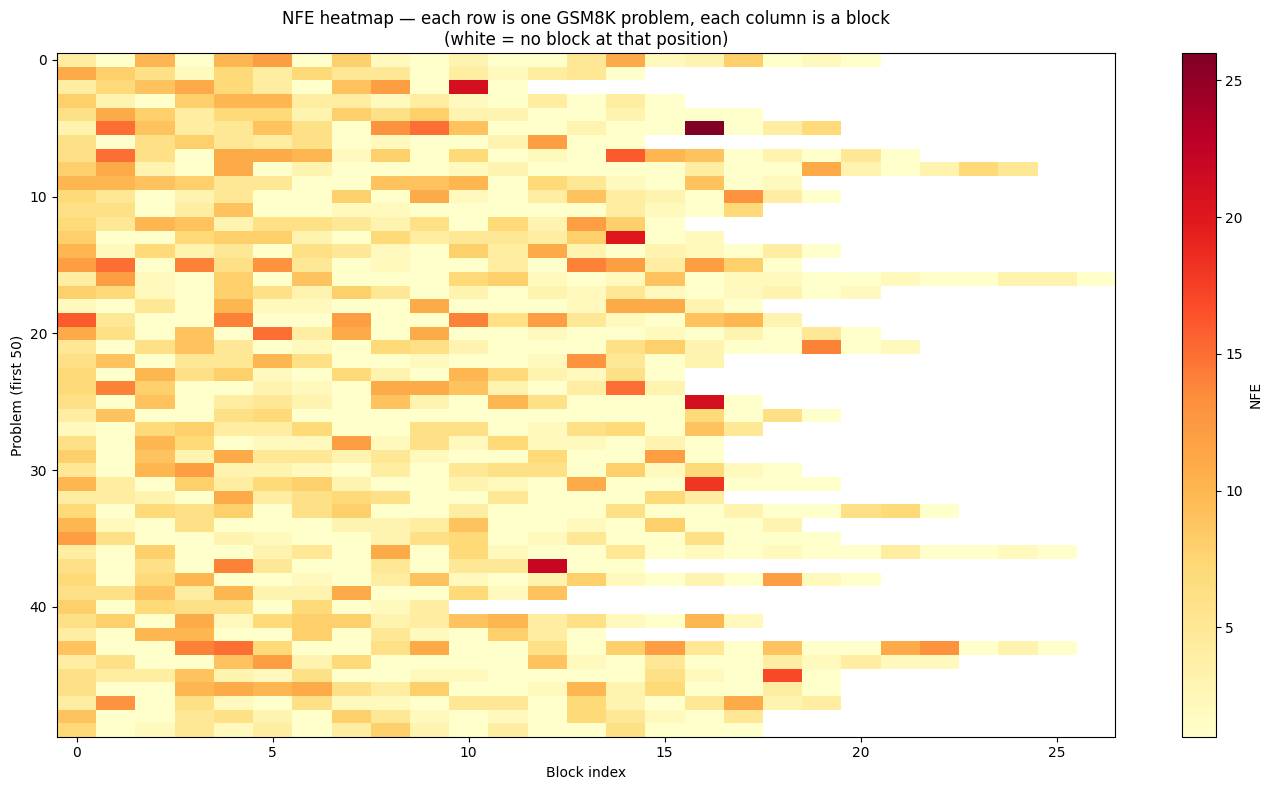

In [10]:
# pivot: rows = problems, cols = block index, values = nfe
N_SHOW = 50  # first 50 problems
sample_ids = blocks["sample_id"].unique()[:N_SHOW]
max_blocks = int(blocks[blocks["sample_id"].isin(sample_ids)]["block_index"].max()) + 1

matrix = np.full((len(sample_ids), max_blocks), np.nan)
for i, sid in enumerate(sample_ids):
    grp = blocks[blocks["sample_id"] == sid]
    for _, row in grp.iterrows():
        matrix[i, int(row["block_index"])] = row["nfe"]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im, ax=ax, label="NFE")
ax.set_xlabel("Block index")
ax.set_ylabel(f"Problem (first {N_SHOW})")
ax.set_title("NFE heatmap — each row is one GSM8K problem, each column is a block\n(white = no block at that position)")
plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_heatmap.png", dpi=150)
plt.show()

## 7. PhaseTuple sequences — ready for phase_predict

Exported 3789 PhaseTuples across 200 problems → ../traces/adablock/gsm8k_phase_tuples.jsonl


/tmp/ipykernel_7840/2869741219.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


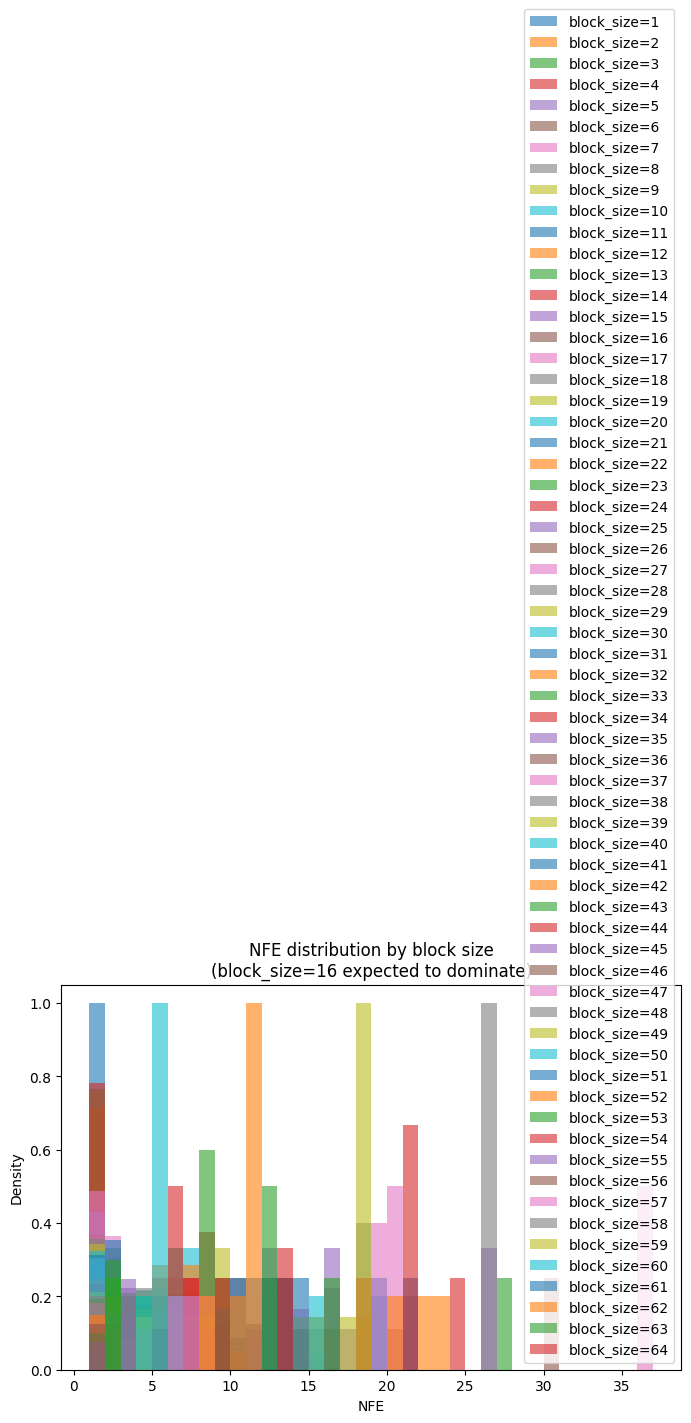

In [11]:
# export flat PhaseTuple sequences for phase_predict training
phase_tuples_path = Path("../traces/adablock/gsm8k_phase_tuples.jsonl")
with phase_tuples_path.open("w") as f:
    for trace in raw:
        tuples = [
            {"block_size": b["block_size"], "nfe": b["nfe"]}
            for b in trace["blocks"]
            if any(t["token_text"] not in {"<|endoftext|>", "<|eot_id|>"} for t in b["tokens"])
        ]
        if tuples:
            f.write(json.dumps({"sample_id": trace["sample_id"], "tuples": tuples}) + "\n")

total_tuples = sum(len(json.loads(l)["tuples"]) for l in phase_tuples_path.read_text().splitlines() if l.strip())
print(f"Exported {total_tuples} PhaseTuples across {len(raw)} problems → {phase_tuples_path}")

# quick look at the (block_size, nfe) joint distribution
fig, ax = plt.subplots(figsize=(8, 5))
block_size_vals = blocks["block_size"].unique()
for bs in sorted(block_size_vals):
    sub = blocks[blocks["block_size"] == bs]["nfe"]
    ax.hist(sub, bins=range(1, int(blocks["nfe"].max()) + 2), alpha=0.6, label=f"block_size={bs}", density=True)
ax.set_xlabel("NFE")
ax.set_ylabel("Density")
ax.set_title("NFE distribution by block size\n(block_size=16 expected to dominate)")
ax.legend()
plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_by_block_size.png", dpi=150)
plt.show()

## 8. Block NFE pattern analysis\n\nLooks at structure *within* a problem's NFE sequence:\n- Transition matrix: what NFE tends to follow what NFE?\n- Trend per response: is NFE rising, falling, or flat?\n- Run-length: how long do "hard" vs "easy" streaks last?\n- Most common NFE subsequences (n-grams)

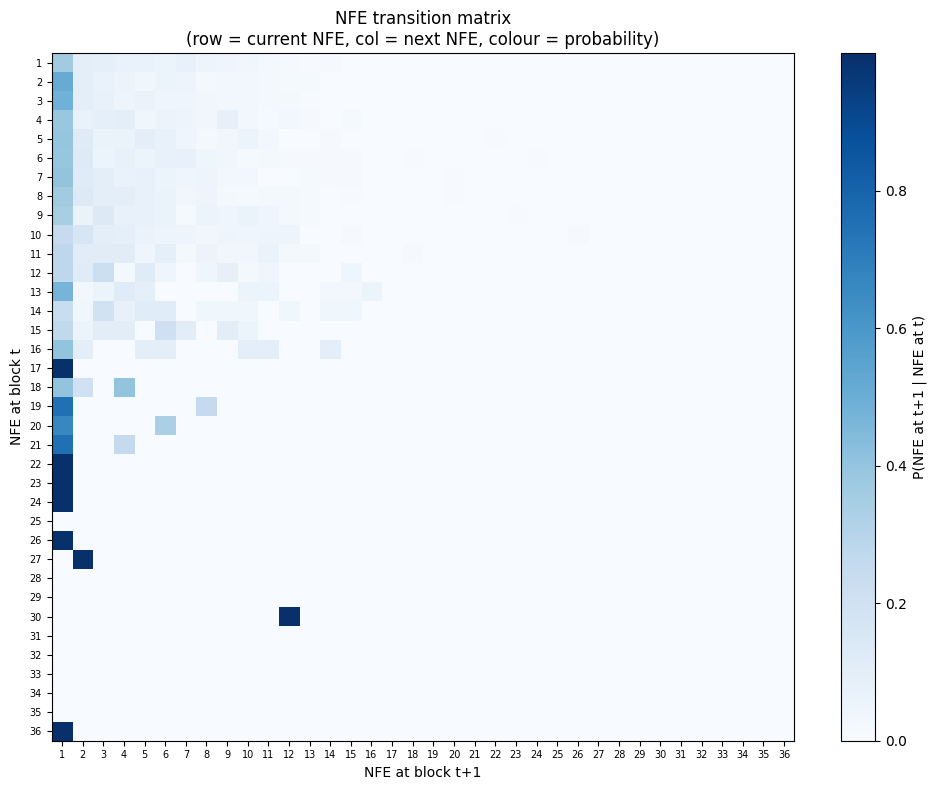

In [12]:
from collections import Counter
from scipy import stats as sp_stats

# ── build per-problem NFE sequences (sorted by block index) ─────────────────
sequences = {}
for sid, grp in blocks.sort_values("block_index").groupby("sample_id"):
    sequences[sid] = grp["nfe"].tolist()

# ── 8a. NFE transition matrix ────────────────────────────────────────────────
nfe_min = int(blocks["nfe"].min())
nfe_max = int(blocks["nfe"].max())
nfe_range = range(nfe_min, nfe_max + 1)
n = nfe_max - nfe_min + 1

trans = np.zeros((n, n), dtype=int)
for seq in sequences.values():
    for t, n_t in enumerate(seq[:-1]):
        i = n_t - nfe_min
        j = seq[t + 1] - nfe_min
        trans[i, j] += 1

# row-normalise to get probabilities
trans_prob = trans / (trans.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(trans_prob, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="P(NFE at t+1 | NFE at t)")
ticks = list(nfe_range)
ax.set_xticks(range(n)); ax.set_xticklabels(ticks, fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(ticks, fontsize=7)
ax.set_xlabel("NFE at block t+1")
ax.set_ylabel("NFE at block t")
ax.set_title("NFE transition matrix\n(row = current NFE, col = next NFE, colour = probability)")
plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_transition_matrix.png", dpi=150)
plt.show()

Trend distribution across problems:
trend
flat       127
falling     73



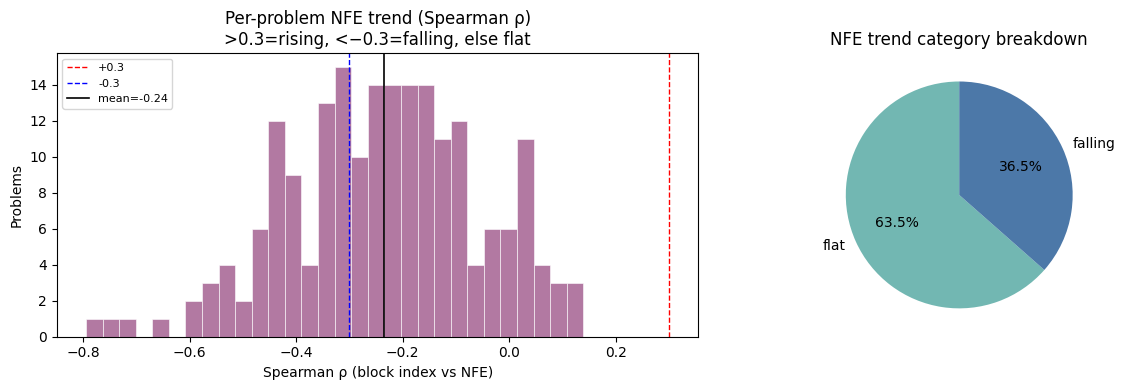

In [13]:
# ── 8b. Trend analysis per response ─────────────────────────────────────────
# Spearman rank correlation between block index and NFE for each problem.
# rho > 0.3  → rising (hard blocks accumulate later)
# rho < -0.3 → falling (hardest blocks early, easier later)
# else       → flat / mixed

TREND_THRESH = 0.3
trend_records = []
for sid, seq in sequences.items():
    if len(seq) < 3:
        trend_records.append({"sample_id": sid, "rho": np.nan, "trend": "short"})
        continue
    rho, _ = sp_stats.spearmanr(range(len(seq)), seq)
    if rho > TREND_THRESH:
        label = "rising"
    elif rho < -TREND_THRESH:
        label = "falling"
    else:
        label = "flat"
    trend_records.append({"sample_id": sid, "rho": rho, "trend": label})

trend_df = pd.DataFrame(trend_records)
counts = trend_df["trend"].value_counts()
print("Trend distribution across problems:")
print(counts.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# histogram of rho values
ax = axes[0]
rho_vals = trend_df["rho"].dropna()
ax.hist(rho_vals, bins=30, edgecolor="white", linewidth=0.4, color="#b279a2")
ax.axvline(TREND_THRESH,  color="red",  linestyle="--", linewidth=1, label=f"+{TREND_THRESH}")
ax.axvline(-TREND_THRESH, color="blue", linestyle="--", linewidth=1, label=f"-{TREND_THRESH}")
ax.axvline(rho_vals.mean(), color="black", linestyle="-", linewidth=1.2, label=f"mean={rho_vals.mean():.2f}")
ax.set_xlabel("Spearman ρ (block index vs NFE)")
ax.set_ylabel("Problems")
ax.set_title("Per-problem NFE trend (Spearman ρ)\n>0.3=rising, <−0.3=falling, else flat")
ax.legend(fontsize=8)

# pie chart of trend categories
ax = axes[1]
labels_pie = [l for l in ["rising", "flat", "falling", "short"] if l in counts.index]
sizes_pie  = [counts[l] for l in labels_pie]
colors_pie = {"rising": "#e45756", "flat": "#72b7b2", "falling": "#4c78a8", "short": "#aaa"}
ax.pie(sizes_pie, labels=labels_pie, colors=[colors_pie[l] for l in labels_pie],
       autopct="%1.1f%%", startangle=90)
ax.set_title("NFE trend category breakdown")

plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_trend_analysis.png", dpi=150)
plt.show()

Global median NFE: 3.0


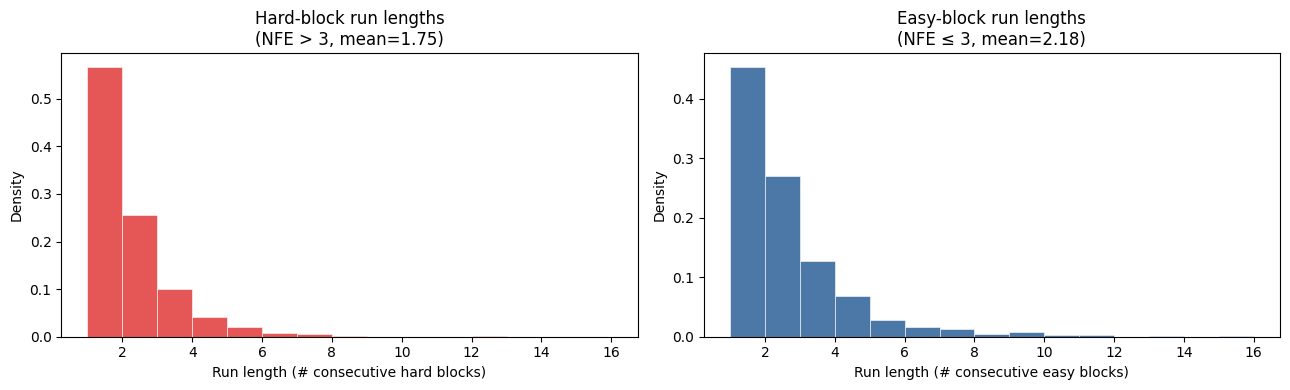

Hard runs — total: 976, mean length: 1.75, max: 12
Easy runs — total: 955, mean length: 2.18, max: 15


In [14]:
# ── 8c. Run-length analysis — hard vs easy streaks ──────────────────────────
# A block is "hard" if NFE > median NFE across the whole dataset, else "easy".
# We measure how many consecutive hard or easy blocks appear in each problem's sequence.

median_nfe = blocks["nfe"].median()
print(f"Global median NFE: {median_nfe}")

def run_lengths(seq, threshold):
    """Return list of (label, length) run-length pairs."""
    runs = []
    if not seq:
        return runs
    current_label = "hard" if seq[0] > threshold else "easy"
    count = 1
    for v in seq[1:]:
        label = "hard" if v > threshold else "easy"
        if label == current_label:
            count += 1
        else:
            runs.append((current_label, count))
            current_label = label
            count = 1
    runs.append((current_label, count))
    return runs

hard_runs, easy_runs = [], []
for seq in sequences.values():
    for label, length in run_lengths(seq, median_nfe):
        if label == "hard":
            hard_runs.append(length)
        else:
            easy_runs.append(length)

hard_runs = np.array(hard_runs)
easy_runs = np.array(easy_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

max_len = max(hard_runs.max(), easy_runs.max())
bins = range(1, max_len + 2)

ax = axes[0]
ax.hist(hard_runs, bins=bins, edgecolor="white", linewidth=0.4, color="#e45756", density=True)
ax.set_xlabel("Run length (# consecutive hard blocks)")
ax.set_ylabel("Density")
ax.set_title(f"Hard-block run lengths\n(NFE > {median_nfe:.0f}, mean={hard_runs.mean():.2f})")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax = axes[1]
ax.hist(easy_runs, bins=bins, edgecolor="white", linewidth=0.4, color="#4c78a8", density=True)
ax.set_xlabel("Run length (# consecutive easy blocks)")
ax.set_ylabel("Density")
ax.set_title(f"Easy-block run lengths\n(NFE ≤ {median_nfe:.0f}, mean={easy_runs.mean():.2f})")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_run_lengths.png", dpi=150)
plt.show()

print(f"Hard runs — total: {len(hard_runs)}, mean length: {hard_runs.mean():.2f}, max: {hard_runs.max()}")
print(f"Easy runs — total: {len(easy_runs)}, mean length: {easy_runs.mean():.2f}, max: {easy_runs.max()}")

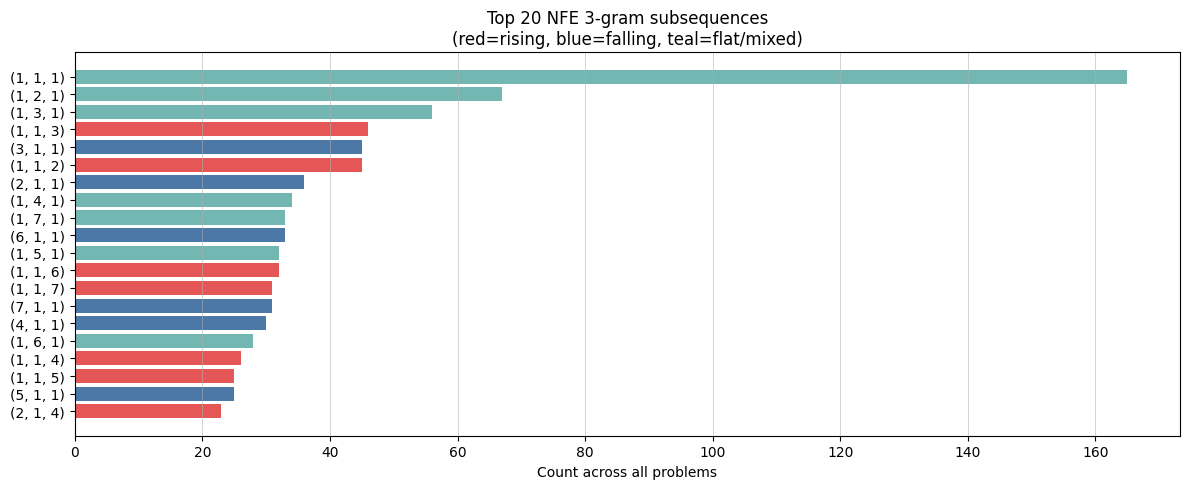


Top 10 NFE 3-grams:
  (1, 1, 1)  →  165 occurrences
  (1, 2, 1)  →  67 occurrences
  (1, 3, 1)  →  56 occurrences
  (1, 1, 3)  →  46 occurrences
  (3, 1, 1)  →  45 occurrences
  (1, 1, 2)  →  45 occurrences
  (2, 1, 1)  →  36 occurrences
  (1, 4, 1)  →  34 occurrences
  (1, 7, 1)  →  33 occurrences
  (6, 1, 1)  →  33 occurrences


In [15]:
# ── 8d. NFE n-gram patterns (most common 3-block subsequences) ───────────────
N = 3  # gram size

ngram_counter: Counter = Counter()
for seq in sequences.values():
    for i in range(len(seq) - N + 1):
        gram = tuple(seq[i : i + N])
        ngram_counter[gram] += 1

TOP_K = 20
top_ngrams = ngram_counter.most_common(TOP_K)
labels = [str(g) for g, _ in top_ngrams]
counts_ng = [c for _, c in top_ngrams]

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ["#e45756" if g[0] < g[-1] else "#4c78a8" if g[0] > g[-1] else "#72b7b2"
              for g, _ in top_ngrams]
bars = ax.barh(labels[::-1], counts_ng[::-1], color=bar_colors[::-1])
ax.set_xlabel("Count across all problems")
ax.set_title(f"Top {TOP_K} NFE {N}-gram subsequences\n(red=rising, blue=falling, teal=flat/mixed)")
ax.grid(axis="x", linewidth=0.4)
plt.tight_layout()
plt.savefig("../traces/adablock/fig_nfe_ngrams.png", dpi=150)
plt.show()

print(f"\nTop 10 NFE {N}-grams:")
for gram, cnt in top_ngrams[:10]:
    print(f"  {gram}  →  {cnt} occurrences")